# NPOR: Plots

In [2]:
import numpy as np
import thebeat
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
import scipy

## Preliminaries

Note that for the code below to run, your jupyter instance must have the root of the project as its working directory.
In VSCode try this: https://stackoverflow.com/questions/55491046/how-to-set-the-running-file-path-of-jupyter-in-vscode

In [3]:
ITIs = pd.read_csv(os.path.join('data', 'experiment', 'processed', 'ITIs.csv'))

## Phase space plots


Let's see what the first 16 sequences one participant look like as phase space plots:

In [3]:
plt.style.use('seaborn-v0_8')

conditions = ['4 events, 400 ms', '4 events, 600 ms', '5 events, 400 ms', '5 events, 600 ms']

for pp_id in ITIs.pp_id.unique():

    fig, axs = plt.subplots(2, 2, figsize=(10, 10), tight_layout=True)
    fig.suptitle('Participant ' + str(pp_id))

    plot_number = 0

    for tempo, tempo_df in ITIs[ITIs.pp_id == pp_id].groupby('stim_tempo_intended'):
        for length, length_df in tempo_df.groupby('length'):
            for sequence_id, sequence_df in length_df.groupby('sequence_id'):
                seq = thebeat.Sequence(length_df.resp_iti.values)
                thebeat.visualization.phase_space_plot(seq, ax=axs[plot_number // 2, plot_number % 2], linewidth=0.005, title = conditions[plot_number])
            plot_number += 1

KeyboardInterrupt: 

## Interval ratios density plots

### All pp's together

/Users/jellevanderwerff/thebeat/thebeat/visualization.py:125: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/Users/jellevanderwerff/thebeat/thebeat/visualization.py:125: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/Users/jellevanderwerff/thebeat/thebeat/visualization.py:125: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/Users/jellevanderwerff/thebeat/thebeat/visualization.py:125: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


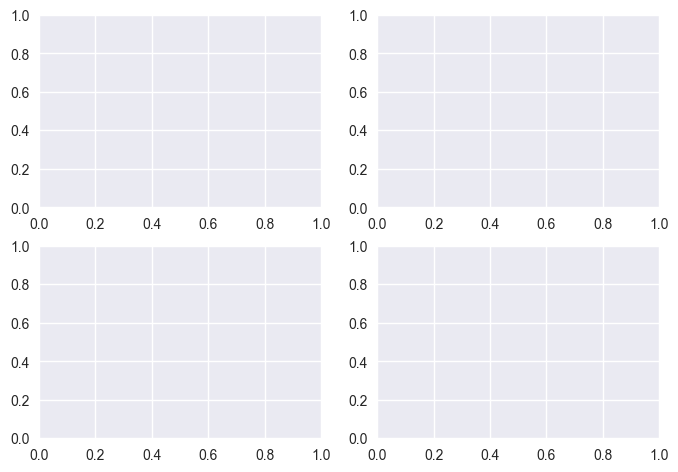

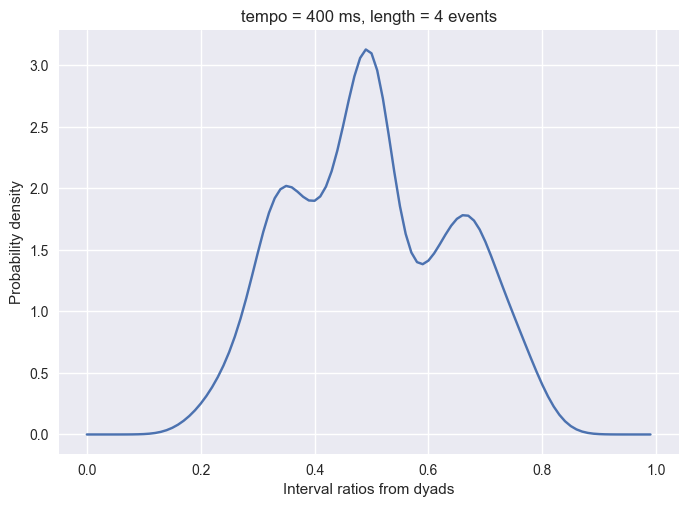

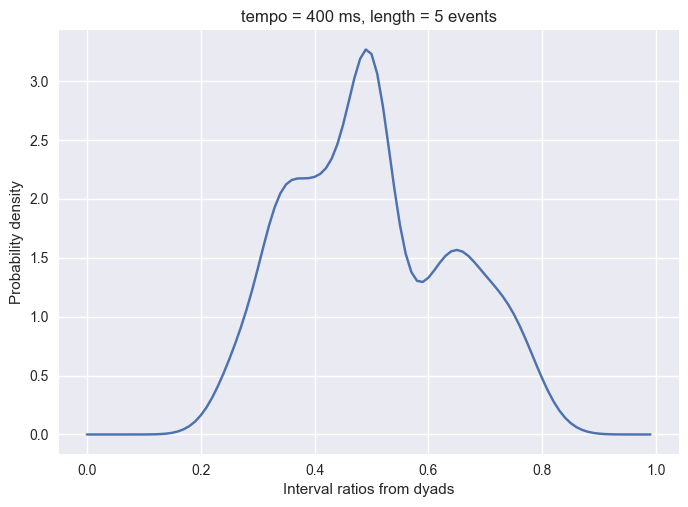

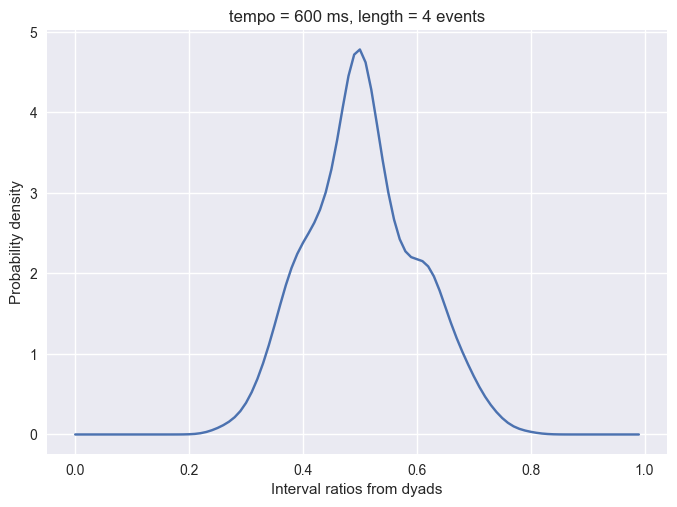

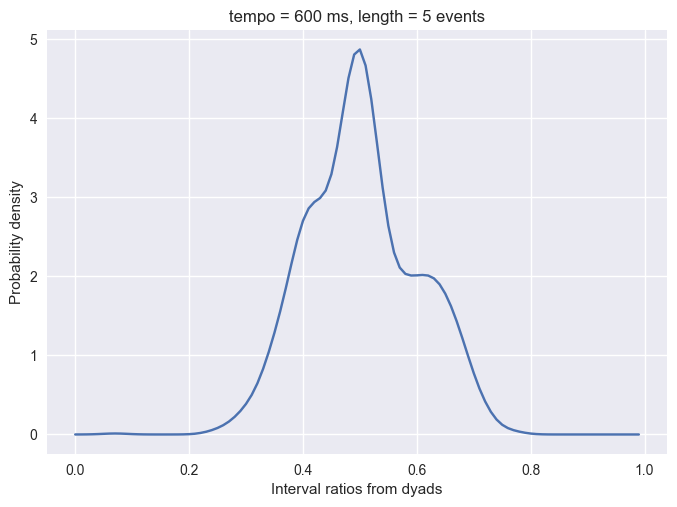

In [ ]:
fig, axs = plt.subplots(2, 2);

plot_number = 0

for tempo, tempo_df in ITIs.groupby('stim_tempo_intended'):
    for length, length_df in tempo_df.groupby('length'):
        seqs = []
        for sequence_id, sequence_df in length  _df.groupby('sequence_id'):
            seqs.append(thebeat.Sequence(sequence_df.resp_iti.values))
        
        axs[plot_number // 2, plot_number % 2] = thebeat.visualization.plot_interval_ratios_density(seqs, title = f'tempo = {tempo} ms, length = {length} events')

        plot_number += 1

### By participant

Let's try to represent the data such that we have a plot for each individual participant, where the different conditions are differently coloured lines.

In [4]:
ratios_df = pd.DataFrame()

for pp_id, pp_df in ITIs.groupby('pp_id'):
    for tempo, tempo_df in pp_df.groupby('stim_tempo_intended'):
        for length, length_df in tempo_df.groupby('length'):
            for sequence_id, sequence_df in length_df.groupby('sequence_id'):
                seq = thebeat.Sequence(sequence_df.resp_iti.values)
                interval_ratios = seq.interval_ratios_from_dyads
                df_piece = pd.DataFrame({
                    'Participant': pp_id,
                    'Condition': f'Tempo = {tempo} ms\nLength = {length} events',
                    'sequence_id': sequence_id,
                    'interval_ratio_i': list(range(1, len(interval_ratios)+1)),
                    'Interval ratio': interval_ratios
                })
                ratios_df = pd.concat([ratios_df, df_piece])

# proper datatypes
ratios_df['Participant'] = ratios_df['Participant'].astype('category')
ratios_df['Condition'] = ratios_df['Condition'].astype('category')
ratios_df['Interval ratio'] = ratios_df['Interval ratio'].astype('float')

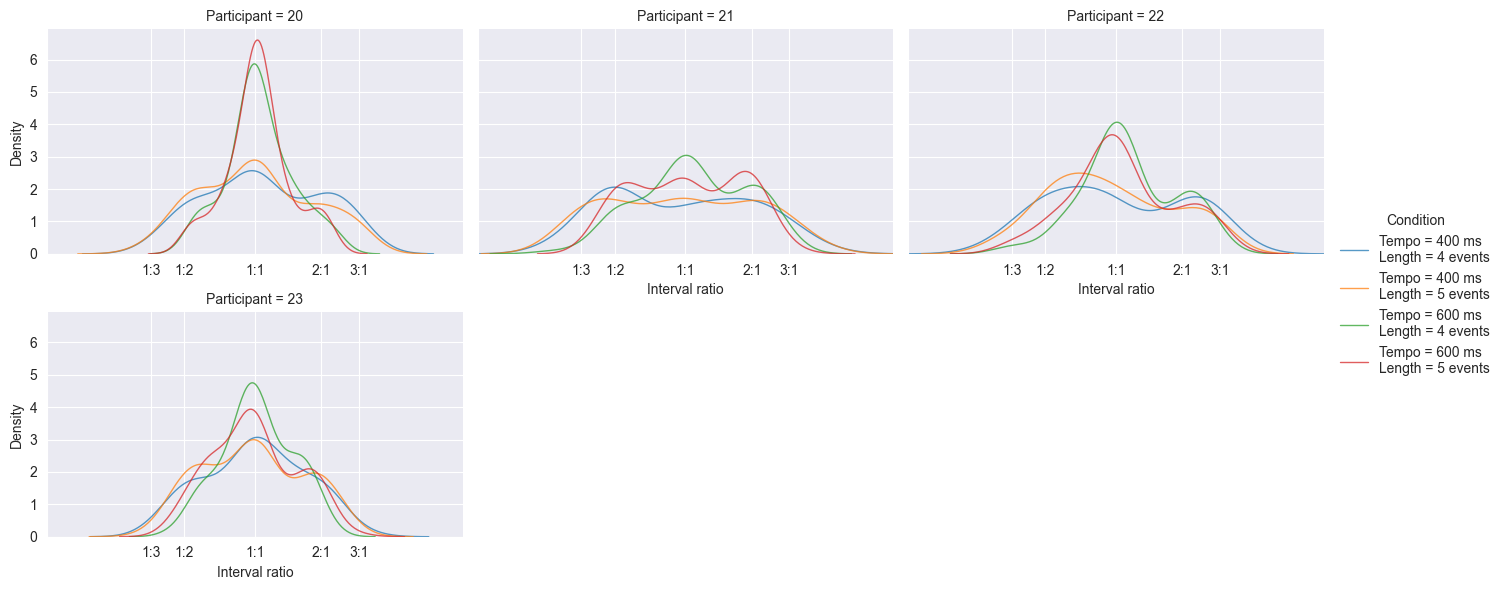

In [5]:
sns.set_style('darkgrid')
g = sns.FacetGrid(ratios_df, col="Participant", col_wrap=3, hue="Condition", height=3, aspect=1.5, sharex=False)
g.map(sns.kdeplot, "Interval ratio", fill=False, alpha=0.75, linewidth=1)
for ax in g.axes.flat:
    ax.set_xlim(0, 1)
    ax.set_xticks([0.25, 0.33, 0.5, 0.66, 0.75])
    ax.set_xticklabels(['1:3', '1:2', '1:1', '2:1', '3:1'])

g.add_legend()

g.savefig(os.path.join('plots', 'ratios_bypp.pdf'), dpi=600)